In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
muratkokludataset_rice_image_dataset_path = kagglehub.dataset_download('muratkokludataset/rice-image-dataset')

print('Data source import complete.')

Using Colab cache for faster access to the 'rice-image-dataset' dataset.
Data source import complete.


In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

Streaming output truncated to the last 5000 lines.
/kaggle/input/rice-image-dataset/Rice_Image_Dataset/Ipsala/Ipsala (10612).jpg
/kaggle/input/rice-image-dataset/Rice_Image_Dataset/Ipsala/Ipsala (4193).jpg
/kaggle/input/rice-image-dataset/Rice_Image_Dataset/Ipsala/Ipsala (4666).jpg
/kaggle/input/rice-image-dataset/Rice_Image_Dataset/Ipsala/Ipsala (11394).jpg
/kaggle/input/rice-image-dataset/Rice_Image_Dataset/Ipsala/Ipsala (7507).jpg
/kaggle/input/rice-image-dataset/Rice_Image_Dataset/Ipsala/Ipsala (11415).jpg
/kaggle/input/rice-image-dataset/Rice_Image_Dataset/Ipsala/Ipsala (13232).jpg
/kaggle/input/rice-image-dataset/Rice_Image_Dataset/Ipsala/Ipsala (11437).jpg
/kaggle/input/rice-image-dataset/Rice_Image_Dataset/Ipsala/Ipsala (9911).jpg
/kaggle/input/rice-image-dataset/Rice_Image_Dataset/Ipsala/Ipsala (11704).jpg
/kaggle/input/rice-image-dataset/Rice_Image_Dataset/Ipsala/Ipsala (7470).jpg
/kaggle/input/rice-image-dataset/Rice_Image_Dataset/Ipsala/Ipsala (1060).jpg
/kaggle/input/rice-

In [ ]:
import numpy as np
import pandas as pd
import cv2 as cv
import os
import csv
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
# 🔹 Select ONLY 2 classes
categories = ['Jasmine', 'Basmati']       # change if needed

def preprocess(image_path):
    """Example preprocessing function - replace with your actual logic"""
    img = cv.imread(image_path)
    if img is None:
        print(f"Warning: Could not read image: {image_path}")
        return None

    # Add your preprocessing steps here (resize, enhance, etc.)
    # Example:
    # img = cv.resize(img, (224, 224))
    # img = cv.cvtColor(img, cv.COLOR_BGR2RGB)  # if needed

    return img

In [ ]:
INPUT_DIR = "/kaggle/input/rice-image-dataset/Rice_Image_Dataset"

In [ ]:
def extract_feature(image_path, label):

    if isinstance(image_path, str):
        img = cv.imread(image_path, cv.IMREAD_GRAYSCALE)
    elif isinstance(image_path, np.ndarray):
        if len(image_path.shape) == 3:
            img = cv.cvtColor(image_path, cv.COLOR_BGR2GRAY)
        else:
            img = image_path.copy()
    else:
        return None

    if img is None:
        return None

    # Threshold
    _, thresh = cv.threshold(img, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU)

    # Morphology
    kernel = np.ones((3,3), np.uint8)
    morphology = cv.morphologyEx(thresh, cv.MORPH_OPEN, kernel)

    # Contours
    contours, _ = cv.findContours(morphology, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)

    if not contours:
        return None

    cnt = max(contours, key=cv.contourArea)

    # Features
    area = cv.contourArea(cnt)
    perimeter = cv.arcLength(cnt, True)

    if len(cnt) >= 5:
        (x, y), (MA, ma), angle = cv.fitEllipse(cnt)

        major_axis = max(MA, ma)
        minor_axis = min(MA, ma)

        eccentricity = np.sqrt(1 - (minor_axis**2 / major_axis**2))
        compactness = (perimeter**2) / (4 * np.pi * area)
    else:
        eccentricity = 0
        compactness = 0   # ✅ FIXED

    return [area, perimeter, eccentricity, compactness, label]

In [ ]:
import csv
import os

OUTPUT_CSV = os.path.join(OUTPUT_DIR, 'rice_features.csv')

header = ['Area', 'Perimeter', 'Eccentricity', 'Compactness', 'Label']

LIMIT = 100  # define once

with open(OUTPUT_CSV, 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(header)

    for rice_type in categories:
        folder_path = os.path.join(INPUT_DIR, rice_type)

        # ✅ Check folder exists
        if not os.path.exists(folder_path):
            print(f"❌ Skipping missing folder: {folder_path}")
            continue

        print(f"Processing variety: {rice_type}...")

        images = [img for img in os.listdir(folder_path)
                  if img.lower().endswith(('.png', '.jpg', '.jpeg'))]

        if not images:
            print(f"⚠️ No images found in {folder_path}")
            continue

        images = images[:LIMIT]

        print(f"→ Using {len(images)} images")

        for filename in images:
            img_path = os.path.join(folder_path, filename)

            features = extract_feature(img_path, rice_type)

            # ✅ safer condition
            if features is not None:
                writer.writerow(features)

print(f"✅ CSV created successfully at: {OUTPUT_CSV}")

Processing variety: Jasmine...
→ Using 100 images
Processing variety: Basmati...
→ Using 100 images
✅ CSV created successfully at: /kaggle/working/rice_features.csv


In [ ]:
import pandas as pd

df = pd.read_csv(OUTPUT_CSV)

df.head()   # shows first 5 rows

,Area,Perimeter,Eccentricity,Compactness,Label
0,5033.0,335.195958,0.941902,1.776482,Jasmine
1,8812.0,454.249781,0.945827,1.863396,Jasmine
2,5277.5,342.776692,0.949689,1.771677,Jasmine
3,5138.5,344.575681,0.953263,1.838751,Jasmine
4,4913.0,330.877198,0.953064,1.773279,Jasmine


In [ ]:
df

,Area,Perimeter,Eccentricity,Compactness,Label
0,5033.0,335.195958,0.941902,1.776482,Jasmine
1,8812.0,454.249781,0.945827,1.863396,Jasmine
2,5277.5,342.776692,0.949689,1.771677,Jasmine
3,5138.5,344.575681,0.953263,1.838751,Jasmine
4,4913.0,330.877198,0.953064,1.773279,Jasmine
...,...,...,...,...,...
195,5597.5,379.865005,0.964641,2.051420,Basmati
196,7323.5,416.894442,0.955686,1.888529,Basmati
197,8054.5,470.208150,0.971863,2.184398,Basmati
198,5831.0,444.333041,0.986243,2.694414,Basmati


In [ ]:
import pandas as pd

df = pd.read_csv(OUTPUT_CSV)

df.head()   # shows first 5 rows

,Area,Perimeter,Eccentricity,Compactness,Label
0,5033.0,335.195958,0.941902,1.776482,Jasmine
1,8812.0,454.249781,0.945827,1.863396,Jasmine
2,5277.5,342.776692,0.949689,1.771677,Jasmine
3,5138.5,344.575681,0.953263,1.838751,Jasmine
4,4913.0,330.877198,0.953064,1.773279,Jasmine


In [ ]:
import pandas as pd

df = pd.read_csv(OUTPUT_CSV)

df.head()   # shows first 5 rows

,Area,Perimeter,Eccentricity,Compactness,Label
0,5033.0,335.195958,0.941902,1.776482,Jasmine
1,8812.0,454.249781,0.945827,1.863396,Jasmine
2,5277.5,342.776692,0.949689,1.771677,Jasmine
3,5138.5,344.575681,0.953263,1.838751,Jasmine
4,4913.0,330.877198,0.953064,1.773279,Jasmine


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# ✅ Select features and label correctly
x = df[['Area', 'Perimeter', 'Eccentricity', 'Compactness']].copy()
y = df['Label'].copy()

# ✅ Convert labels (strings → numbers)
le = LabelEncoder()
y = le.fit_transform(y)

# ✅ Split dataset (80% train, 20% test)
x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.2,
    random_state=42,
    stratify=y   # 🔥 keeps class balance (important)
)

# ✅ Print shapes
print("x_train:", x_train.shape)
print("x_test :", x_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

x_train: (160, 4)
x_test : (40, 4)
y_train: (160,)
y_test : (40,)


In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(160, 4)
(40, 4)
(160,)
(40,)


In [ ]:
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(x_train, y_train)

KNeighborsClassifier()

In [ ]:
y_pred = knn_model.predict(x_test)

In [ ]:
def predict(image_path, model, label_encoder):

    # Step 1: Extract features directly from image path
    extracted_data = extract_feature(image_path, 'Unknown')

    if extracted_data is None:
        return None

    # Step 2: Take only numeric features
    numeric_features = extracted_data[:4]

    # Step 3: Convert to DataFrame
    feature_df = pd.DataFrame(
        [numeric_features],
        columns=['Area', 'Perimeter', 'Eccentricity', 'Compactness']
    )

    # Step 4: Predict
    pred_num = model.predict(feature_df)

    # Step 5: Convert label back
    pred_cat = label_encoder.inverse_transform(pred_num)

    return pred_cat[0], feature_df

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [ ]:
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(x_train, y_train)   # if already trained → skip

KNeighborsClassifier()

In [ ]:
def predict(image_path, model, label_encoder):

    # Extract features directly
    features = extract_feature(image_path, 'Unknown')

    if features is None:
        return None, None

    # Take numeric values
    numeric_features = features[:4]

    # Convert to DataFrame
    feature_df = pd.DataFrame(
        [numeric_features],
        columns=['Area', 'Perimeter', 'Eccentricity', 'Compactness']
    )

    # Predict
    pred = model.predict(feature_df)

    return pred[0], feature_df

In [ ]:
test_image = '/kaggle/input/rice-image-dataset/Rice_Image_Dataset/Jasmine/Jasmine (100).jpg'

In [ ]:
predicted_class, extracted_features = predict(test_image, knn_model, le)

print("Prediction:", predicted_class)
print(extracted_features)

Prediction: 1
     Area  Perimeter  Eccentricity  Compactness
0  5251.5  325.88939      0.941029     1.609338


✅ Model Accuracy: 0.85

✅ Confusion Matrix:
 [[16  3]
 [ 3 18]]

✅ Classification Report:

              precision    recall  f1-score   support

           0       0.84      0.84      0.84        19
           1       0.86      0.86      0.86        21

    accuracy                           0.85        40
   macro avg       0.85      0.85      0.85        40
weighted avg       0.85      0.85      0.85        40



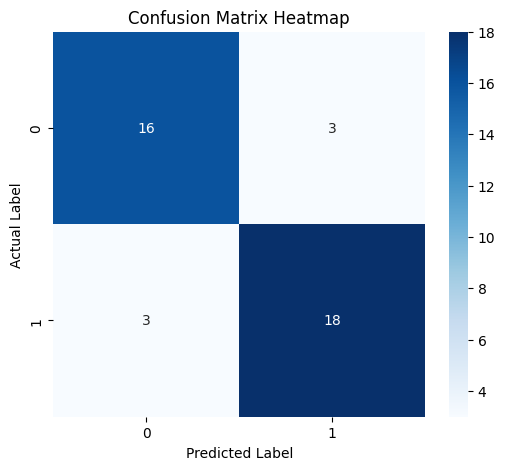

In [ ]:
# ==============================
# ✅ MODEL EVALUATION (FINAL STEP)
# ==============================

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Predict on test data
y_pred = knn_model.predict(x_test)

# Step 2: Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("✅ Model Accuracy:", accuracy)

# Step 3: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\n✅ Confusion Matrix:\n", cm)

# Step 4: Classification Report
print("\n✅ Classification Report:\n")
print(classification_report(y_test, y_pred))

# Step 5: Heatmap Visualization (VERY IMPORTANT FOR PROJECT)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix Heatmap")
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score

# Predict
y_pred = knn_model.predict(x_test)

# Accuracy in percentage
accuracy = accuracy_score(y_test, y_pred) * 100

print(f"✅ Model Accuracy: {accuracy:.2f}%")

✅ Model Accuracy: 85.00%
